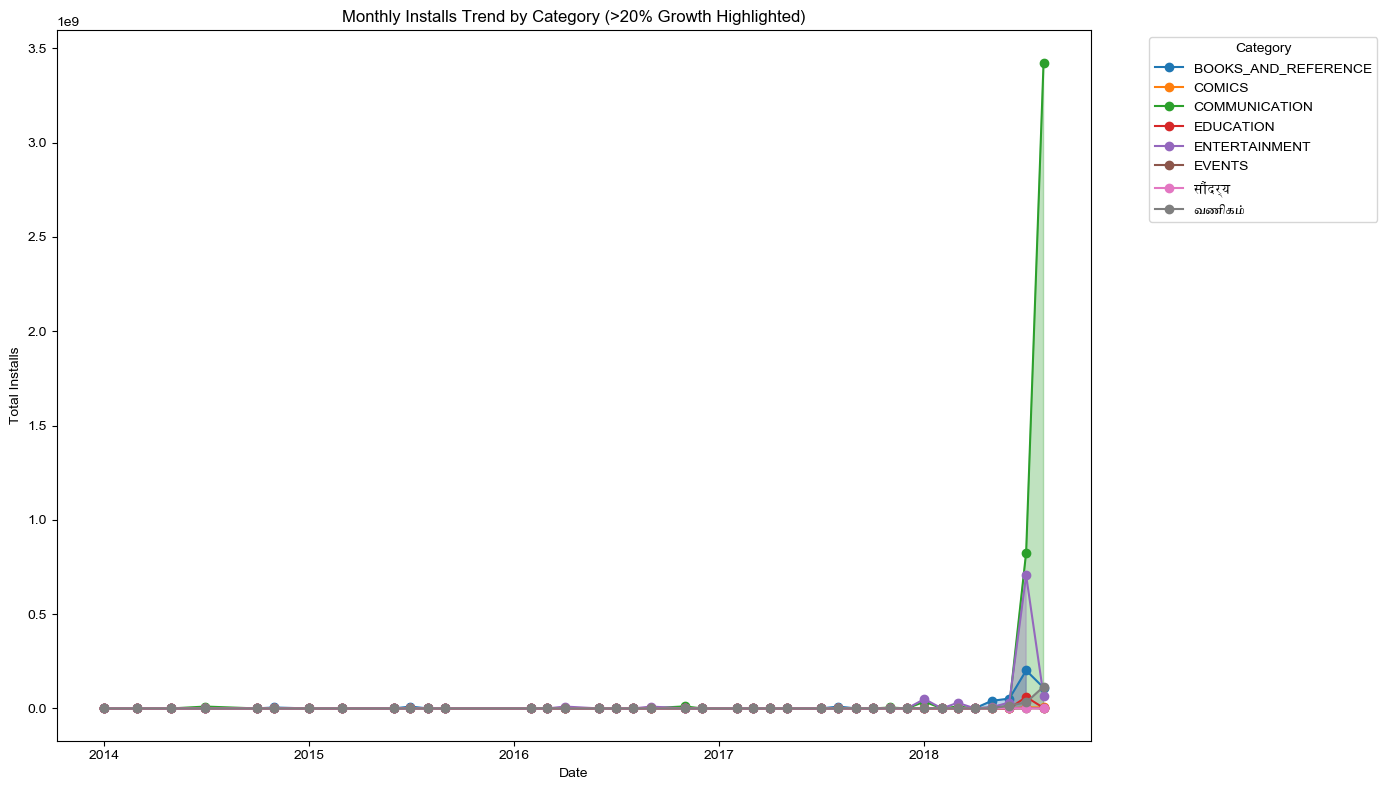

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz
plt.rcParams['font.family'] = 'Arial Unicode MS'

df = pd.read_csv('googleplaystore.csv')

df['Installs'] = df['Installs'].astype(str).str.replace(r'[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Date'] = pd.to_datetime(df['Last Updated'], errors='coerce')

df = df.dropna(subset=['App', 'Category', 'Date', 'Installs'])
df['App_lower'] = df['App'].str.lower()

mask = (
    (df['Reviews'] > 500) &
    (~df['App_lower'].str.startswith(('x', 'y', 'z'))) &
    (~df['App_lower'].str.contains('s')) &
    (df['Category'].str.startswith(('E', 'C', 'B')))
)
filtered_df = df[mask].copy()

translation_map = {
    'BEAUTY': 'सौंदर्य',
    'BUSINESS': 'வணிகம்',
    'DATING': 'Partnersuche'
}
filtered_df['Category'] = filtered_df['Category'].replace(translation_map)

filtered_df['Month'] = filtered_df['Date'].dt.to_period('M').dt.to_timestamp()
monthly_data = filtered_df.groupby(['Month', 'Category'])['Installs'].sum().unstack(fill_value=0).sort_index()

ist = pytz.timezone('Asia/Kolkata')
current_time = datetime.now(ist).time()
start_time = datetime.strptime("18:00", "%H:%M").time()
end_time = datetime.strptime("21:00", "%H:%M").time()

if start_time <= current_time <= end_time:
    pct_change = monthly_data.pct_change()
    fig, ax = plt.subplots(figsize=(14, 8))
    
    for category in monthly_data.columns:
        x = monthly_data.index
        y = monthly_data[category]
        line, = ax.plot(x, y, label=category, marker='o')
        
        condition = pct_change[category] > 0.20
        ax.fill_between(x, 0, y, where=condition, color=line.get_color(), alpha=0.3)
        
    ax.set_title('Monthly Installs Trend by Category (>20% Growth Highlighted)', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Installs')
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print(f"Chart hidden. Current IST Time: {current_time.strftime('%I:%M %p')}.")